# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty. 

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [5]:
df_hh_income = pd.read_csv(r'D:\PycharmProjects\day-100-fatalForce\Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv(r'D:\PycharmProjects\day-100-fatalForce\Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv(r'D:\PycharmProjects\day-100-fatalForce\Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv(r'D:\PycharmProjects\day-100-fatalForce\Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv(r'D:\PycharmProjects\day-100-fatalForce\Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames? 
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [7]:
print("Median Household Income:", df_hh_income.shape)
print("Poverty:",df_pct_poverty.shape)
print("High School:",df_pct_completed_hs.shape)
print("Race:",df_share_race_city.shape)
print("Fatalities:",df_fatalities.shape)

Median Household Income: (29322, 3)
Poverty: (29329, 3)
High School: (29329, 3)
Race: (29268, 7)
Fatalities: (2535, 14)


In [10]:
print("Income columns:",df_hh_income.columns.tolist())
print("Poverty columns:",df_pct_poverty.columns.tolist())
print("High School columns:",df_pct_completed_hs.columns.tolist())
print("Race columns:",df_share_race_city.columns.tolist())
print("Fatalities columns:",df_fatalities.columns.tolist())

Income columns: ['Geographic Area', 'City', 'Median Income']
Poverty columns: ['Geographic Area', 'City', 'poverty_rate']
High School columns: ['Geographic Area', 'City', 'percent_completed_hs']
Race columns: ['Geographic area', 'City', 'share_white', 'share_black', 'share_native_american', 'share_asian', 'share_hispanic']
Fatalities columns: ['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender', 'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level', 'flee', 'body_camera']


In [13]:
print("Income missing values:")
print(df_hh_income.isna().sum())
print("\nPoverty missing values:")
print(df_pct_poverty.isna().sum())
print("\nHigh School missing values:")
print(df_pct_completed_hs.isna().sum())
print("\nRace missing values:")
print(df_share_race_city.isna().sum())
print("\nFatalities missing values:")
print(df_fatalities.isna().sum())

Income missing values:
Geographic Area     0
City                0
Median Income      51
dtype: int64

Poverty missing values:
Geographic Area    0
City               0
poverty_rate       0
dtype: int64

High School missing values:
Geographic Area         0
City                    0
percent_completed_hs    0
dtype: int64

Race missing values:
Geographic area          0
City                     0
share_white              0
share_black              0
share_native_american    0
share_asian              0
share_hispanic           0
dtype: int64

Fatalities missing values:
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera           

In [15]:
print("Income duplicates:",df_hh_income.duplicated().sum())
print("Poverty duplicates:",df_pct_poverty.duplicated().sum())
print("High School duplicates:",df_pct_completed_hs.duplicated().sum())
print("Race duplicates:",df_share_race_city.duplicated().sum())
print("Fatalities duplicates:",df_fatalities.duplicated().sum())

Income duplicates: 0
Poverty duplicates: 0
High School duplicates: 0
Race duplicates: 0
Fatalities duplicates: 0


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate. 

In [18]:
#income data
df_hh_income['Median Income']=(
    df_hh_income['Median Income']
    .astype(str)
    .str.replace(',','',regex=False)
    .str.replace('+','',regex=False)
)
df_hh_income['Median Income']=pd.to_numeric(
    df_hh_income['Median Income'],
    errors='coerce'
)

#poverty & high school data
df_pct_poverty['poverty_rate']=pd.to_numeric(
    df_pct_poverty['poverty_rate'],
    errors='coerce'
)
df_pct_completed_hs['percent_completed_hs']=pd.to_numeric(
    df_pct_completed_hs['percent_completed_hs'],
    errors='coerce'
)

#race data
race_columns=[
    'share_white',            
    'share_black',            
    'share_native_american',    
    'share_asian',              
    'share_hispanic'
]
for column in race_columns:
    df_share_race_city[column]=pd.to_numeric(
        df_share_race_city[column],
        errors='coerce'
    )   

In [23]:
print(df_hh_income.isna().sum())
print(df_pct_poverty.isna().sum())
print(df_pct_completed_hs.isna().sum())
print(df_share_race_city.isna().sum())
print(df_fatalities.isna().sum())

Geographic Area       0
City                  0
Median Income      1913
dtype: int64
Geographic Area      0
City                 0
poverty_rate       201
dtype: int64
Geographic Area           0
City                      0
percent_completed_hs    197
dtype: int64
Geographic area           0
City                      0
share_white              20
share_black              20
share_native_american    20
share_asian              20
share_hispanic           20
dtype: int64
id                           0
name                         0
date                         0
manner_of_death              0
armed                        9
age                         77
gender                       0
race                       195
city                         0
state                        0
signs_of_mental_illness      0
threat_level                 0
flee                        65
body_camera                  0
dtype: int64


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

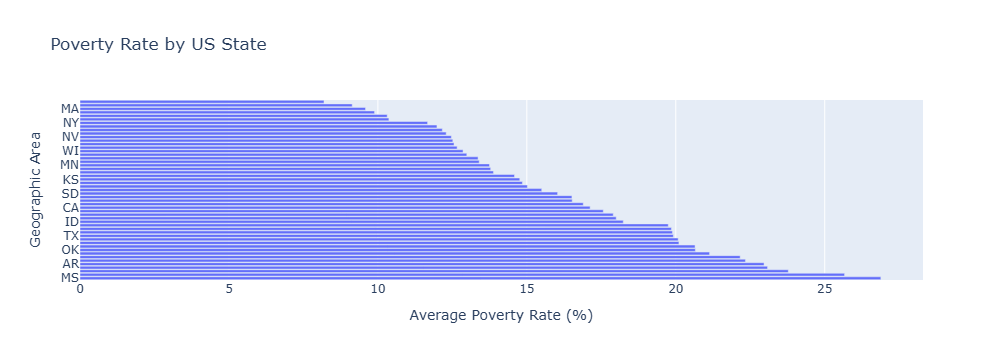

In [24]:
poverty_by_state=(
    df_pct_poverty
    .groupby('Geographic Area')['poverty_rate']
    .mean()
    .sort_values(ascending=False)
)

fig=px.bar(
    poverty_by_state,
    x=poverty_by_state.values,
    y=poverty_by_state.index,
    orientation='h',
    title='Poverty Rate by US State',
    labels={'x':'Average Poverty Rate (%)','y':'state'}
)
fig.show()

# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

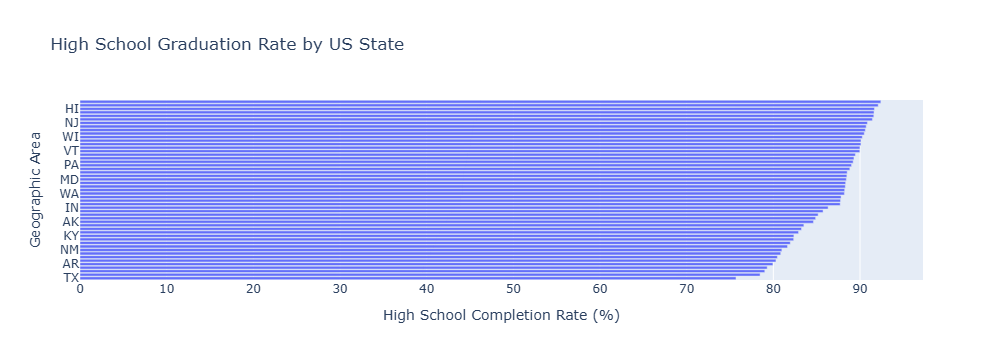

In [28]:
hs_by_state=(
    df_pct_completed_hs
    .groupby('Geographic Area')['percent_completed_hs']
    .mean()
    .sort_values()
)

fig=px.bar(
    hs_by_state,
    x=hs_by_state.values,
    y=hs_by_state.index,
    orientation='h',
    title='High School Graduation Rate by US State',
    labels={'x':'High School Completion Rate (%)','y':'state'}
)
fig.show()

# Visualise the Relationship between Poverty Rates and High School Graduation Rates

#### Create a line chart with two y-axes to show if the rations of poverty and high school graduation move together.  

In [29]:
state_education_poverty=pd.DataFrame({
    'Poverty Rate':poverty_by_state,
    'High School Completion':hs_by_state
}).dropna()

state_education_poverty.head()

,Poverty Rate,High School Completion
Geographic Area,,
AK,19.85,84.63
AL,20.65,80.30
AR,22.96,79.95
AZ,25.67,80.47
CA,17.12,81.96


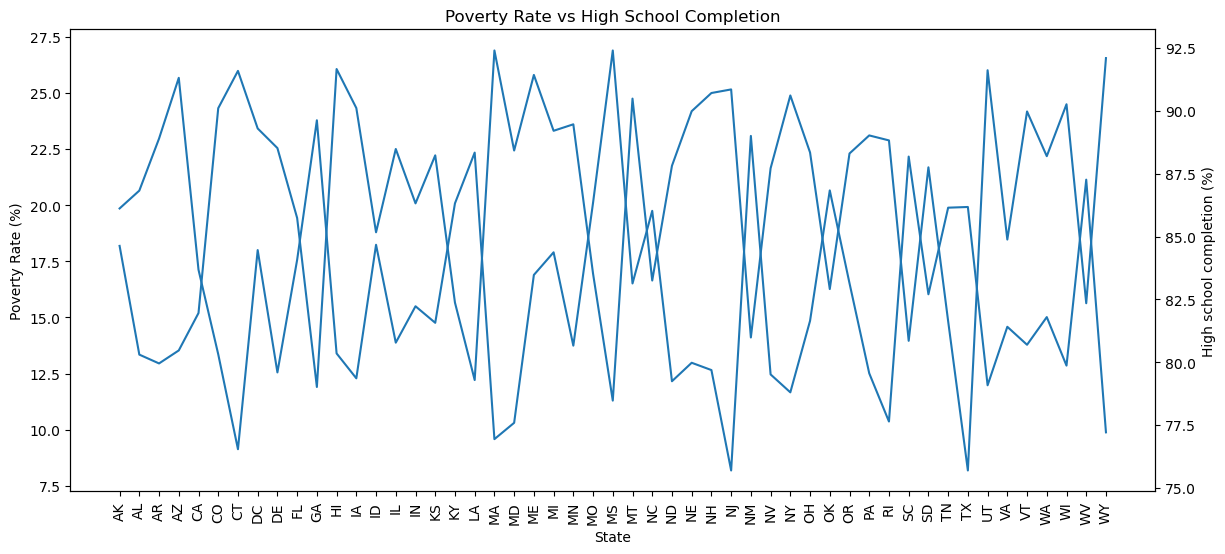

In [32]:
fig,ax1=plt.subplots(figsize=(14,6))

ax1.plot(
    state_education_poverty.index,
    state_education_poverty['Poverty Rate'],
    label='Poverty Rate'
)

ax1.set_xlabel('State')
ax1.set_ylabel('Poverty Rate (%)')
ax1.tick_params(axis='x', rotation=90)

ax2=ax1.twinx()

ax2.plot(
    state_education_poverty.index,
    state_education_poverty['High School Completion'],
    label='High School Completion'
)

ax2.set_ylabel('High school completion (%)')

plt.title('Poverty Rate vs High School Completion')
plt.show()

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

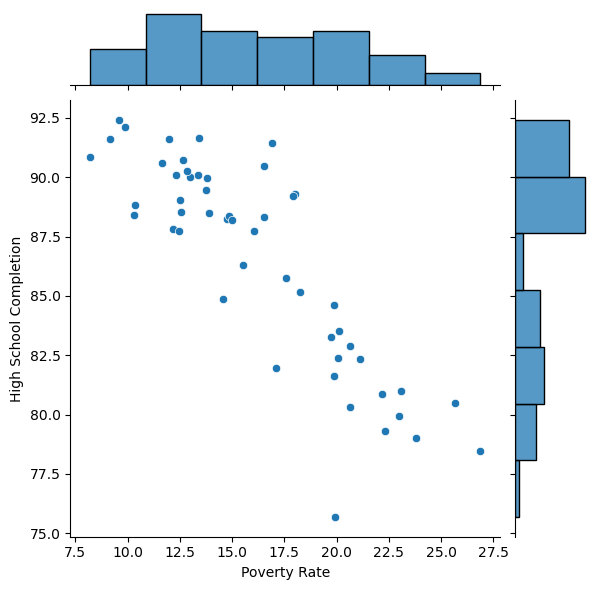

In [33]:
sns.jointplot(
    data=state_education_poverty,
    x='Poverty Rate',
    y='High School Completion',
    kind='scatter'
)
plt.show()

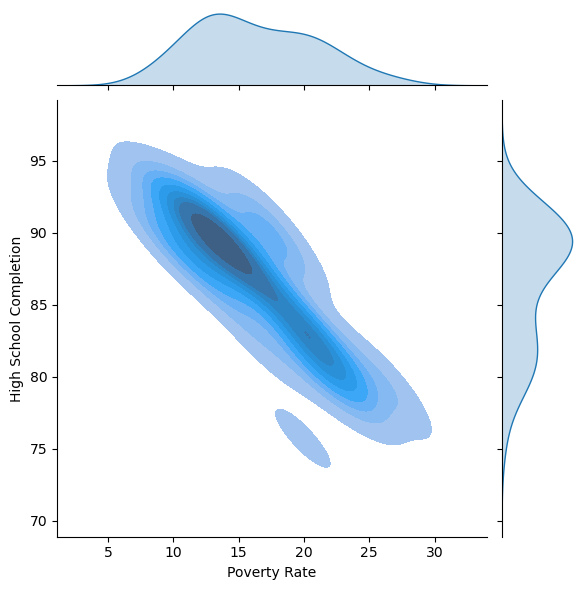

In [36]:
sns.jointplot(
    data=state_education_poverty,
    x='Poverty Rate',
    y='High School Completion',
    kind='kde',
    fill=True
)
plt.show()

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio. 

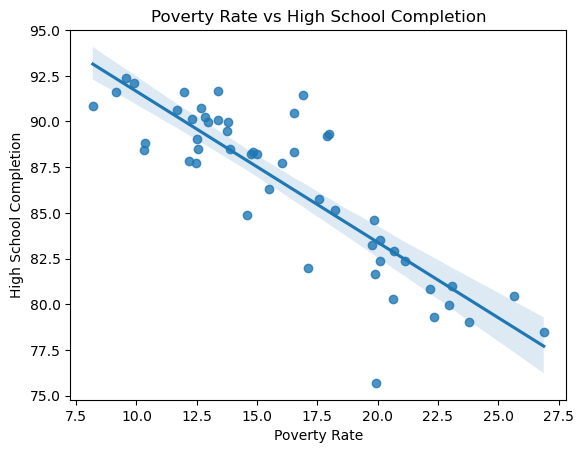

In [37]:
sns.regplot(
    data=state_education_poverty,
    x='Poverty Rate',
    y='High School Completion'
)
plt.title('Poverty Rate vs High School Completion')
plt.show()

# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections. 

In [38]:
state_race=(
    df_share_race_city
    .groupby('Geographic area')[
        [
           'share_white',            
            'share_black', 
            'share_hispanic', 
            'share_asian',  
            'share_native_american'                                      
        ]
    ]
    .mean()
)
state_race.head()

,share_white,share_black,share_hispanic,share_asian,share_native_american
Geographic area,,,,,
AK,45.65,0.57,2.15,1.39,45.86
AL,72.51,23.32,2.98,0.48,0.66
AR,78.45,16.30,4.27,0.48,0.76
AZ,59.93,0.95,20.14,0.73,28.59
CA,71.87,2.69,29.65,5.57,1.72


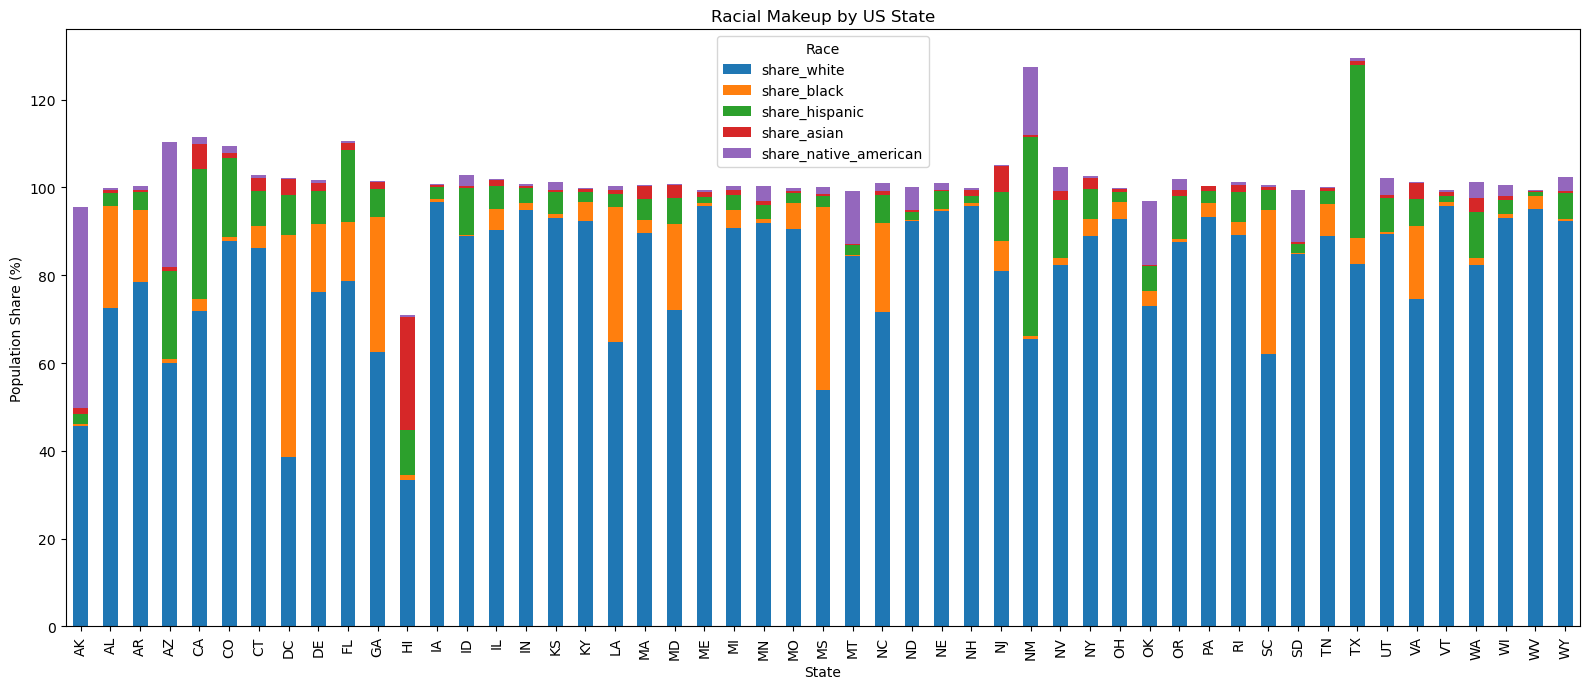

In [39]:
state_race.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 7)
)

plt.title('Racial Makeup by US State')
plt.xlabel('State')
plt.ylabel('Population Share (%)')
plt.xticks(rotation=90)
plt.legend(title='Race')
plt.tight_layout()
plt.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

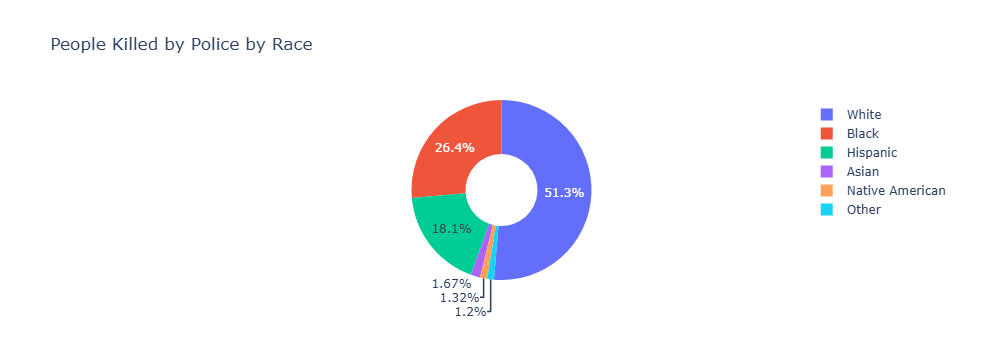

In [40]:
race_counts=df_fatalities['race'].value_counts()

race_labels={
    'W':'White',
    'B':'Black',
    'H':'Hispanic',
    'A':'Asian',
    'N':'Native American',
    'O':'Other'    
}
race_counts.index=race_counts.index.map(
    lambda x: race_labels.get(x,x)
)

fig=px.pie(
    values=race_counts.values,
    names=race_counts.index,
    hole=0.4,
    title='People Killed by Police by Race'    
)
fig.show()

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women. 

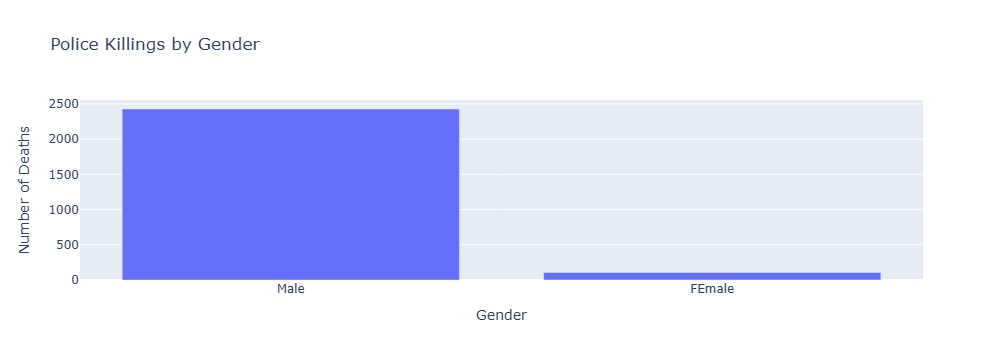

In [41]:
gender_counts=df_fatalities['gender'].value_counts()

gender_counts.index=gender_counts.index.map({
    'M':'Male',
    'F':'FEmale'
})
fig=px.bar(
    x=gender_counts.index,
    y=gender_counts.values,
    title='Police Killings by Gender',
    labels={
        'x': 'Gender',
        'y': 'Number of Deaths'
    }    
)
fig.show()

# Create a Box Plot Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death? 

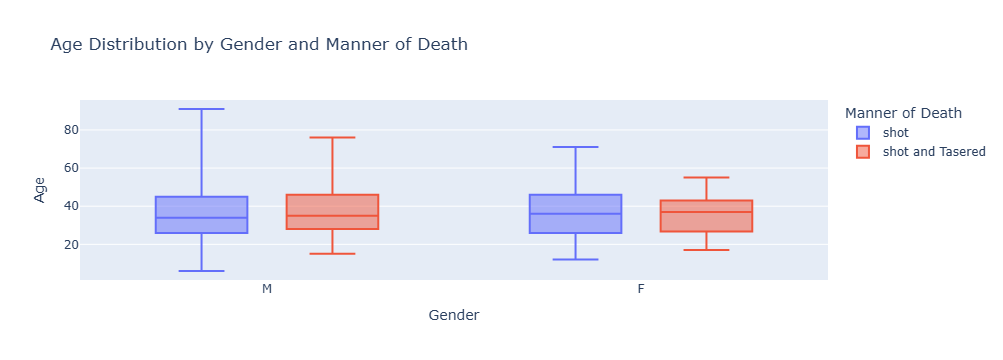

In [43]:
fig=px.box(
    df_fatalities,
    x='gender',
    y='age',
    color='manner_of_death',
    points=False,
    title='Age Distribution by Gender and Manner of Death',
    labels={'gender':'Gender', 'age':'Age', 'manner_of_death':'Manner of Death' }
)
fig.show()

# Were People Armed? 

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed? 

In [44]:
#armerd/unarmed categories
def armed_status(value):
    if pd.isna(value):
        return 'Unkonown'
    elif value.lower()=='unarmed':
        return 'Unarmed'
    else:
        return 'Armed'

df_fatalities['armed_status']=df_fatalities['armed'].apply(armed_status)
armed_counts = df_fatalities['armed_status'].value_counts()
armed_counts

armed_status
Armed       2355
Unarmed      171
Unkonown       9
Name: count, dtype: int64

In [45]:
#percentage
armed_percentage=(
    df_fatalities['armed_status']
    .value_counts(normalize=True)*100
)
armed_percentage

armed_status
Armed      92.90
Unarmed     6.75
Unkonown    0.36
Name: proportion, dtype: float64

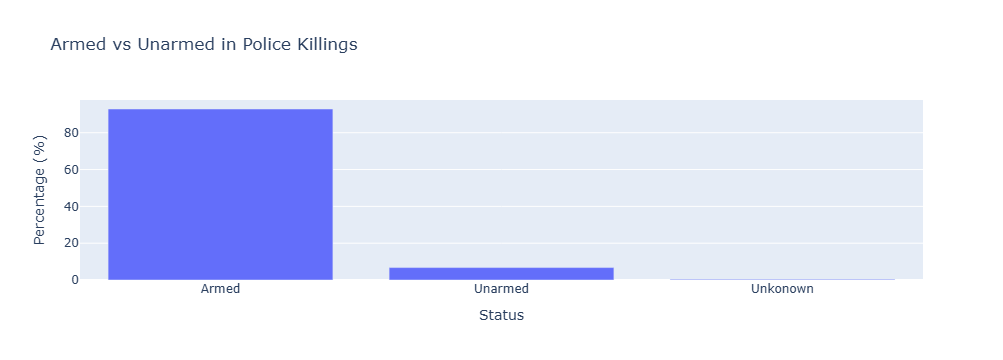

In [47]:
#charts
fig=px.bar(
    x=armed_percentage.index,
    y=armed_percentage.values,
    title='Armed vs Unarmed in Police Killings',
    labels={'x':'Status', 'y':'Percentage (%)'}
)
fig.show()

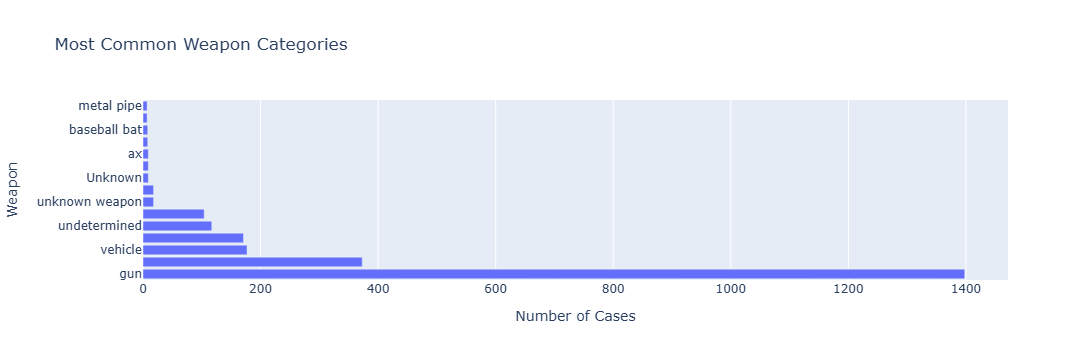

In [48]:
#weapon types
weapon_counts=df_fatalities['armed'].fillna('Unknown').value_counts()

fig=px.bar(
    weapon_counts.head(15),
    x=weapon_counts.head(15).values,
    y=weapon_counts.head(15).index,
    orientation='h',
    title='Most Common Weapon Categories',
    labels={'x':'Number of Cases', 'y':'Weapon'}
)

fig.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [51]:
under_25=df_fatalities['age'].lt(25).sum()
total_with_age=df_fatalities['age'].notna().sum()
percentage_under_25=under_25/total_with_age * 100
print(f"Percentage under 25: {percentage_under_25:.2f}%")

Percentage under 25: 18.31%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police. 

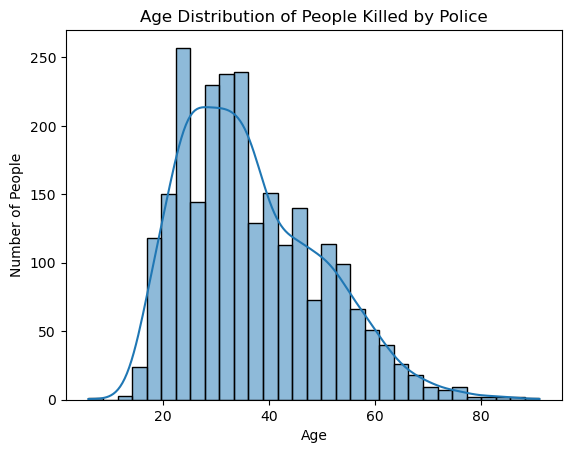

In [53]:
age_data=df_fatalities['age'].dropna()

sns.histplot(
    age_data,
    kde=True
)
plt.title('Age Distribution of People Killed by Police')
plt.xlabel('Age')
plt.ylabel('Number of People')
plt.show()

Create a seperate KDE plot for each race. Is there a difference between the distributions? 

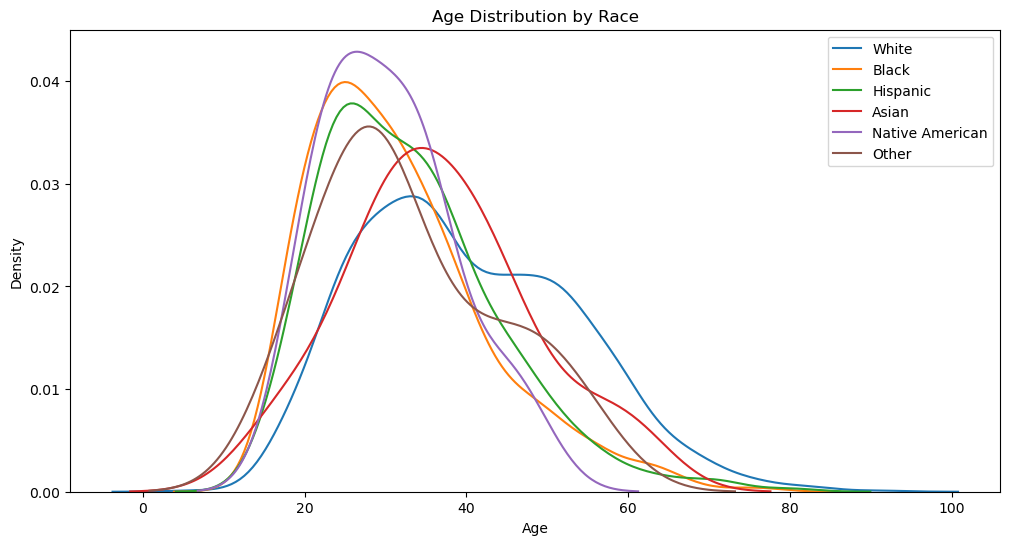

In [54]:
race_names={
    'W':'White',
    'B':'Black',
    'H':'Hispanic',
    'A':'Asian',
    'N':'Native American',
    'O':'Other'    
}
plt.figure(figsize=(12,6))

for race_code,race_name in race_names.items():
    age_data=df_fatalities[
        df_fatalities['race'] == race_code    
    ]['age'].dropna()

    if len(age_data) > 1:
        sns.kdeplot(
            age_data,
            label=race_name
        )

plt.title('Age Distribution by Race')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

# Race of People Killed

Create a chart that shows the total number of people killed by race. 

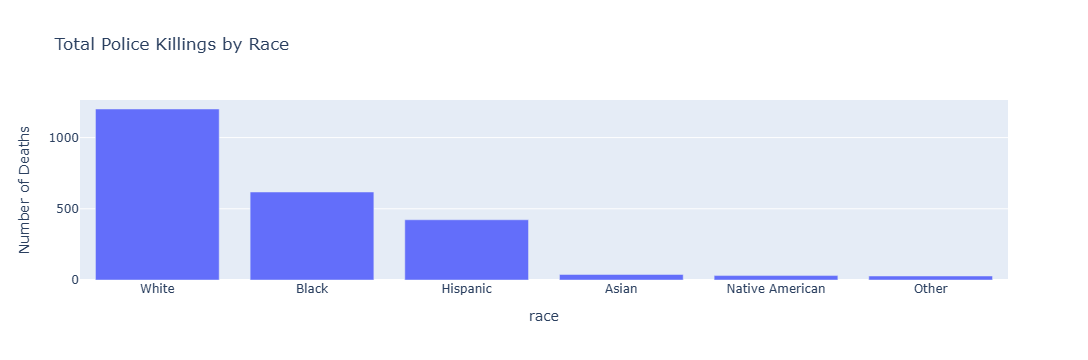

In [56]:
race_counts=df_fatalities['race'].value_counts()

race_counts.index=race_counts.index.map(
    lambda x:race_labels.get(x, x)
)

fig=px.bar(
    race_counts,
    x=race_counts.index,
    y=race_counts.values,
    title='Total Police Killings by Race',
    labels={'x':'Race', 'y':'Number of Deaths'}
)
fig.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

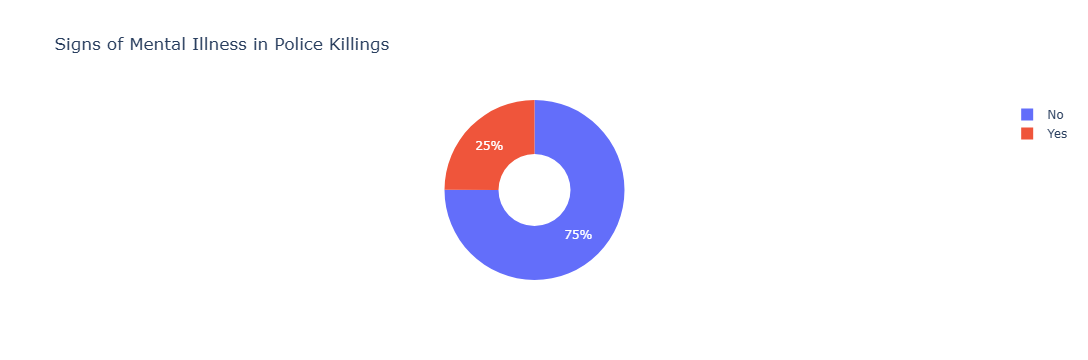

In [60]:
mental_counts = df_fatalities['signs_of_mental_illness'].map({
    True: 'Yes',
    False: 'No'
}).value_counts()

fig = px.pie(
    values=mental_counts.values,
    names=mental_counts.index,
    hole=0.4,
    title='Signs of Mental Illness in Police Killings'
)

fig.show()

# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

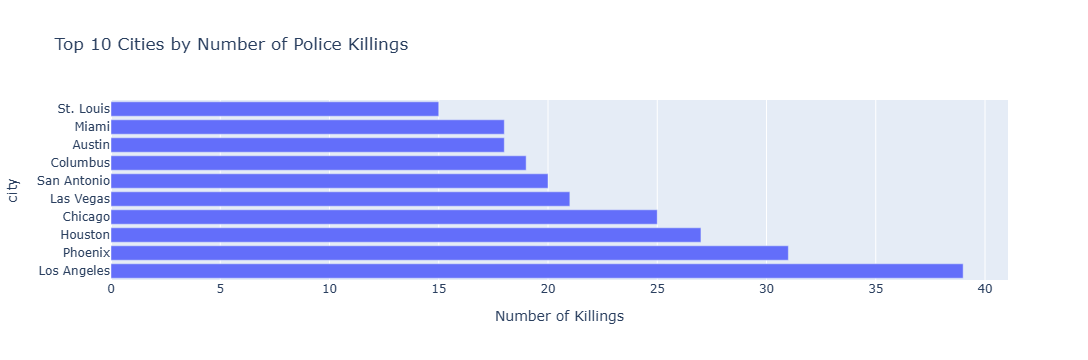

In [61]:
top_cities=df_fatalities['city'].value_counts().head(10)

fig=px.bar(
    top_cities,
    x=top_cities.values,
    y=top_cities.index,
    orientation='h',
    title='Top 10 Cities by Number of Police Killings',
    labels={
        'x': 'Number of Killings',
        'y': 'City'
    }
)
fig.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city. 

In [64]:
top_city_names=df_fatalities['city'].value_counts().head(10).index

city_race_population=(
    df_share_race_city[
        df_share_race_city['City'].isin(top_city_names)
    ]   
    .groupby('City')[
        [
            'share_white',
            'share_black',
            'share_hispanic',
            'share_asian',
            'share_native_american'            
        ]
    
    ]
    .mean()
)
city_race_population

,share_white,share_black,share_hispanic,share_asian,share_native_american
City,,,,,


In [66]:
city_race_killings=pd.crosstab(
    df_fatalities[
        df_fatalities['city'].isin(top_city_names)
    ]['city'],
    df_fatalities[
        df_fatalities['city'].isin(top_city_names)
    ]['race']
)

city_race_killings=city_race_killings.rename(
    columns=race_labels
)

city_race_killings

race,Asian,Black,Hispanic,Native American,Other,White
city,,,,,,
Austin,0,3,2,0,0,13
Chicago,0,21,1,0,0,2
Columbus,0,11,0,0,1,6
Houston,1,15,6,1,0,3
Las Vegas,0,3,5,0,0,9
Los Angeles,1,10,19,0,0,6
Miami,0,8,6,0,0,3
Phoenix,0,2,11,3,0,12
San Antonio,0,3,12,0,0,3


# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty? 

In [68]:
killing_by_state=(
    df_fatalities['state']
    .value_counts()
    .rename_axis('state')
    .reset_index(name='killings')
)
killing_by_state

,state,killings
0,CA,424
1,TX,225
2,FL,154
3,AZ,118
4,OH,79
5,OK,78
6,CO,74
7,GA,70
8,NC,69
9,MO,64


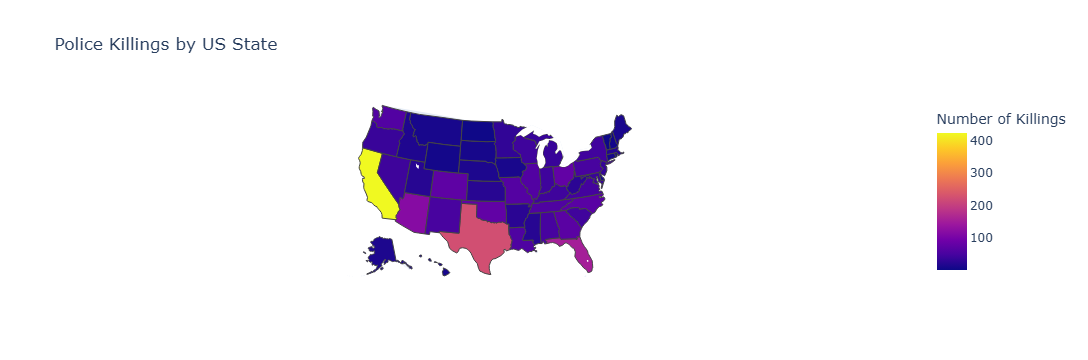

In [71]:
fig=px.choropleth(
    killing_by_state,
    locations='state',
    locationmode='USA-states',
    color='killings',
    scope='usa',
    title='Police Killings by US State',
    labels={'killings':'Number of Killings'}    
)
fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data? 

In [73]:
df_fatalities['date']=pd.to_datetime(
    df_fatalities['date'],
    format='mixed'
)

In [74]:
killings_over_time=(
    df_fatalities
    .set_index('date')
    .resample('ME')
    .size()
)

killings_over_time.head()

date
2015-01-31    70
2015-02-28    78
2015-03-31    87
2015-04-30    88
2015-05-31    85
Freq: ME, dtype: int64

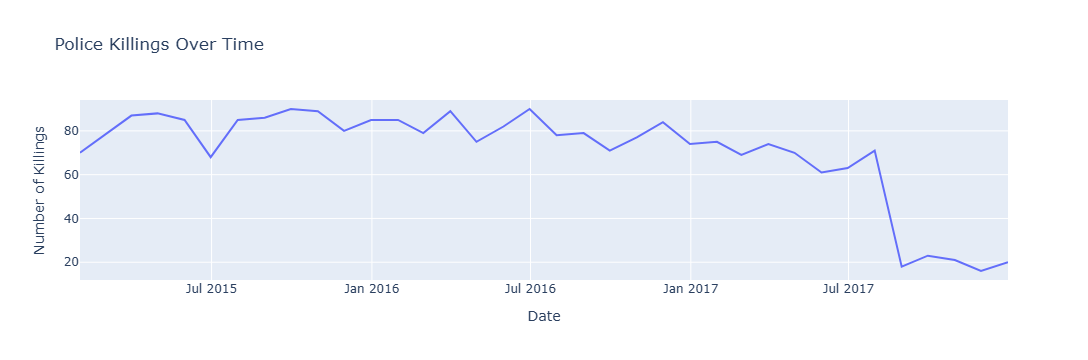

In [75]:
fig=px.line(
    x=killings_over_time.index,
    y=killings_over_time.values,
    title='Police Killings Over Time',
    labels={'x':'Date', 'y':'Number of Killings'}
)

fig.show()

# Epilogue

Now that you have analysed the data yourself, read [The Washington Post's analysis here](https://www.washingtonpost.com/graphics/investigations/police-shootings-database/).